# LSST SN Ia Simulation Pipeline (Rubin Nightsum)

Forward-model SN Ia light curves with the LSSTCam simulated nightsum cadence using `lightcurvelynx`.

**Survey**: LSSTCam simulated nightsum visits (`lsstcam_visits_all_nights.csv`, built by `build_rubin_nightsum.py` from https://s3df.slac.stanford.edu/data/rubin/sim-data/schedview/reports/)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/rubin_nightly/data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import sncosmo

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler, ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag, ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper, SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

# Cap the number of simulated SNe for a fast smoke test; set to None for a full run.
NSN_TEST_LIMIT = None
SKIP_SIM = True  # Set to True to skip the simulation and load existing results from disk.
SKIP_LCFIT = True  # Set to True to skip light curve fitting and load existing results from disk.

# Dustmap choice: "sfdmap2" | "dustmap_sfd"
DUSTMAP = "dustmap_sfd"  # dustmap_sfd = DustmapWrapper(SFDQuery()); sfdmap2 = SFDMap (sfdmap2 library)

SIM_PARAMS = {
    # Cosmology
    "H0": 70.0,
    "Omega_m": 0.315,
    "w": -1.0,
    # Redshift range
    "zmin": 0.001,
    "zmax": 1.0,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.15,
    "beta": 3.15,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.973,  "x1_sigma_minus": 1.472, "x1_sigma_plus": 0.222,
    "c_mean":  -0.054,  "c_sigma_minus":  0.043, "c_sigma_plus":  0.101,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.1,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
    "tmin": 60960,
    "tmax": 62786,
}

## 3. Load LSST Visit Table

Loads `lsstcam_visits_all_nights.csv` (built by `build_rubin_nightsum.py` from Rubin's schedview nightsum reports) via `LSSTObsTable.from_nightly_summary_table()`.

Two things this needs to handle that the SV-visits table didn't:
- The CSV has 272 columns; `from_nightly_summary_table()` drops any row with a NaN in *any* column, so we select only the columns it actually needs before calling it.
- The CSV includes non-science frames (`img_type` in acq/cwfs/engtest/focus) and calibration `band` values (`none`, `other:pinhole`) that the original SV-visits source didn't have; we keep only `img_type == "science"` rows.

In [5]:
_csv_path = "lsstcam_visits_all_nights.csv"

_cols_needed = list(LSSTObsTable._nightly_visits_colmap.values()) + ["img_type"]
_raw = pd.read_csv(_csv_path, usecols=_cols_needed)

print(f"Loaded {len(_raw):,} raw visit rows")
_raw = _raw[_raw["img_type"] == "science"].drop(columns=["img_type"])
print(f"Kept {len(_raw):,} science visit rows")

obstable = LSSTObsTable.from_nightly_summary_table(_raw)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

Loaded 104,142 raw visit rows
Kept 81,193 science visit rows
Visit table loaded: 77,710 observations
MJD range: 60847.1 – 61231.4
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [6]:
sky_coverage = obstable.estimate_coverage()
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 26712 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
print(f"Expected SNe Ia = {nsn:,}")
nsn = int(nsn * 0.2)
print(f"Simulating 20% of expected SNe Ia = {nsn:,}")

if NSN_TEST_LIMIT is not None:
    nsn = min(nsn, NSN_TEST_LIMIT)
    print(f"NSN_TEST_LIMIT set -- capping to {nsn:,} SNe Ia for this run")

Survey length = 1.05 years
Solid angle   = 8.1368 sr  (26,712 deg²)
Expected SNe Ia = 3,297,706
Simulating 20% of expected SNe Ia = 659,541


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

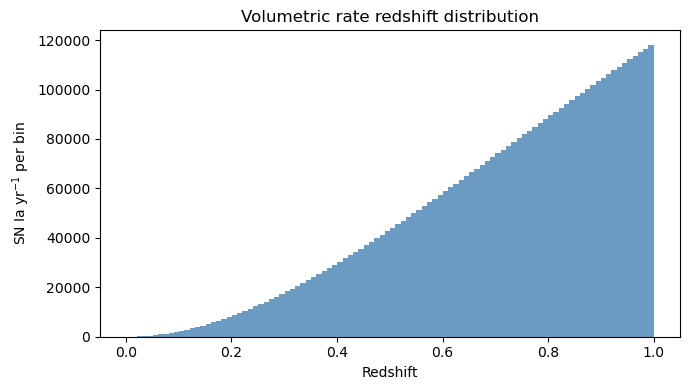

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ApproximateMOCSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — Gaussian($\mu=0$, $\sigma=1$)
- **c** — Gaussian($\mu=0$, $\sigma=0.1$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.12$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [10]:
# RA/Dec: uniform over the opsim footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(opsim, node_label="radec")
moc = obstable.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Asymmetric Gaussian SALT3 parameter priors
def asymmetric_gaussian_pdf(x, mu, sigma_minus, sigma_plus):
    norm_factor = np.sqrt(2 / np.pi) / (sigma_minus + sigma_plus)
    return np.where(
        x < mu,
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_minus) ** 2),
        norm_factor * np.exp(-0.5 * ((x - mu) / sigma_plus) ** 2),
    )
def x1_pdf(x):
    return asymmetric_gaussian_pdf(x, SIM_PARAMS["x1_mean"], SIM_PARAMS["x1_sigma_minus"], SIM_PARAMS["x1_sigma_plus"])
def c_pdf(c):
    return asymmetric_gaussian_pdf(c, SIM_PARAMS["c_mean"], SIM_PARAMS["c_sigma_minus"], SIM_PARAMS["c_sigma_plus"])

x1_func = SamplePDF(x1_pdf, node_label="x1")
c_func = SamplePDF(c_pdf, node_label="c")
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)

# Milky Way dust extinction — choose backend via DUSTMAP
print(f"Dust map: {DUSTMAP}")
if DUSTMAP == "dustmap_sfd":
    from dustmaps.sfd import SFDQuery
    mwextinction = DustmapWrapper(SFDQuery(), ra=source.ra, dec=source.dec, node_label="mwext")
elif DUSTMAP == "sfdmap2":
    mwextinction = SFDMap(ra=source.ra, dec=source.dec, node_label="mwext")
else:
    raise ValueError(f"Unknown DUSTMAP: {DUSTMAP!r}. Choose 'sfdmap2' or 'dustmap_sfd'.")

ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction,
                              r_v=3.1, frame='observer', backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Dust map: dustmap_sfd
Source model built successfully.


## 8. Run Simulation

In [11]:
obstable.columns

Index(['filter', 'airmass', 'time', 'sky_bg_e', 'zp_mag_e', 'ra', 'dec',
       'exptime', 'rotation', 'seeing', 'skybrightness', 'maglim', 'zp',
       'psf_footprint'],
      dtype='str')

In [12]:
if not SKIP_SIM:
    param_cols = [
        "source.t0",
        "source.x0",
        "source.x1",
        "source.c",
        "source.redshift",
        "source.ra",
        "source.dec",
        "x0_func.distmod",
    ]
    obstable_save_cols = ["zp"]

    NJOBS = 8
    BATCH_SIZE = 5000
    parallel_executor = "loky"  # Options: "loky", "dask", None
    if parallel_executor == "loky":
        try:
            import loky
            executor = loky.get_reusable_executor(max_workers=4)
            results = simulate_lightcurves(
                model=source,
                num_samples=nsn,
                survey_info=obstable,
                passbands=passbands,
                param_cols=param_cols,
                obstable_save_cols=obstable_save_cols,
                rng=RNG,
                num_jobs=NJOBS,
                batch_size=BATCH_SIZE,
                executor=executor,
            )
        except ImportError:
            print("Loky is not installed")
    elif parallel_executor == "dask":
        try:
            import dask.distributed

            with dask.distributed.Client() as client:
                print(f"Dask dashboard link: {client.dashboard_link}")
                results = simulate_lightcurves(
                    model=source,
                    num_samples=nsn,
                    survey_info=obstable,
                    passbands=passbands,
                    param_cols=param_cols,
                    obstable_save_cols=obstable_save_cols,
                    rng=RNG,
                    num_jobs=NJOBS,
                    batch_size=BATCH_SIZE,
                    executor=client,
                )
        except ImportError:
            print("Dask is not installed")
    else:
        executor = None
        results = simulate_lightcurves(
            model=source,
            num_samples=nsn,
            survey_info=obstable,
            passbands=passbands,
            param_cols=param_cols,
            obstable_save_cols=obstable_save_cols,
            rng=RNG,
            num_jobs=NJOBS,
            batch_size=BATCH_SIZE,
            executor=executor,
        )
    print(f"Generated {len(results)} light curves")
    print(results["lightcurve"][0])

    print(f"Simulated {len(results):,} SNe Ia")
    results.head()

## 9. Save Results

In [13]:
# save results
if not SKIP_SIM:
    output_path = "outputs/rubin_nightsum_snia_results.parquet"
    output_path = Path(output_path)
    output_path.parent.mkdir(exist_ok=True)
    results.to_parquet(output_path)
    print(f"Saved to {output_path}")

In [14]:
lightcurves = read_parquet("outputs/rubin_nightsum_snia_results.parquet")

## 10. Apply Selections

In [15]:
# calculate detection flag
lightcurves = lightcurves.drop(columns=["params"])
lightcurves = lightcurves.dropna(subset="lightcurve")

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset="lightcurve")
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset="lightcurve")
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 659376


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1393: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After droppoing saturation: nsn= 659376


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1393: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 108777


In [16]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux, mjd, filter, z, t0, n_phases=7, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases, unique_idx = np.unique(phases, return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases <= 40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [17]:
pass_quality_cut = lightcurves_after_detection.map_rows(lc_quality_cuts, columns=["lightcurve.flux","lightcurve.mjd", "lightcurve.filter", "z", "t0"],
                                                        row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx, "pass_quality_cuts"] = True

After quality cuts: nsn= 4383


## 11. Diagnostics

Quick sanity checks on the simulated population.

In [18]:
results = lightcurves_after_quality_cut

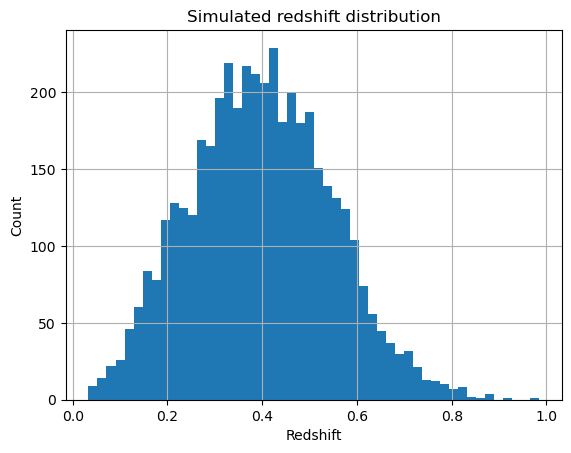

In [19]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

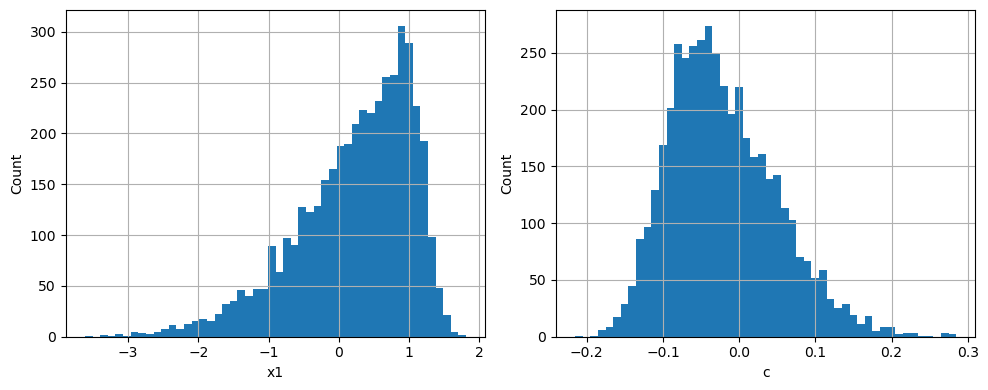

In [20]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

             mjd filter         flux      fluxerr  flux_perfect  survey_idx  \
0   61026.315445      i  1422.963394   144.552518   1474.803486           0   
1   61030.305310      r  2528.590268   165.299600   2618.720111           0   
2   61042.289835      i  4317.878138   223.766839   4074.415120           0   
3   61042.313518      i  4162.355684   198.258992   4074.964154           0   
4   61044.171983      y  3837.630470   599.919433   3633.063780           0   
5   61045.216316      y  5385.654832  1034.249084   3634.898684           0   
6   61045.276001      y  4359.543460   757.661839   3634.290329           0   
7   61046.279740      y  4823.656325   742.321742   3611.575316           0   
8   61050.277688      z  3957.735405   206.041125   4036.827625           0   
9   61051.295835      z  3975.153081   425.247311   3933.904506           0   
10  61056.269503      r  2898.039679   114.161383   2771.150776           0   
11  61056.290757      g   752.131181    90.927802   

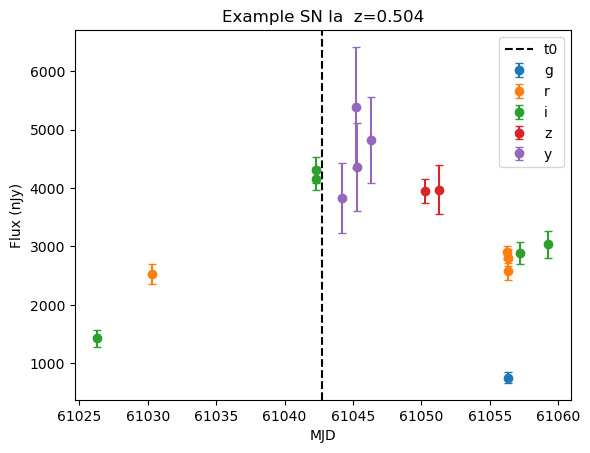

In [21]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [22]:
from utils.lcfit import fit_single_lc

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4, 4),
                                 "c": (-0.4, 0.4)},
                         phase_range=(-10, 40),
                         modelcov=False):
    return fit_single_lc(lc, mpbounds=bounds, phase_range=phase_range, modelcov=modelcov)

In [23]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

success       1.0
ncall        79.0
             ... 
id           12.0
fit_error     NaN
Length: 54, dtype: float64

In [24]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [25]:
%%time
if not SKIP_LCFIT:
    results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in lc_to_fit.iterrows())
    result_df = pd.DataFrame(results)
    result_df.to_csv("outputs/rubin_nightsum_snia_lcfit_results.csv", index=True)

CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns
Wall time: 3.1 μs


In [26]:
result_df = pd.read_csv("outputs/rubin_nightsum_snia_lcfit_results.csv", index_col=0)

In [27]:
from scipy.stats import chi2

saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
saltparcuts &= (result_df.success == True)
saltparcuts &= (result_df.t0_err < 1)
saltparcuts &= (result_df.x1_err < 1)
saltparcuts &= (result_df.c_err < 0.1)

reduced = result_df.chisq / result_df.ndof
p_value = 1 - chi2.cdf(result_df.chisq, df=result_df.ndof)

saltparcuts &= p_value > 1e-7

In [28]:
np.sum(saltparcuts)

np.int64(2672)

<Axes: >

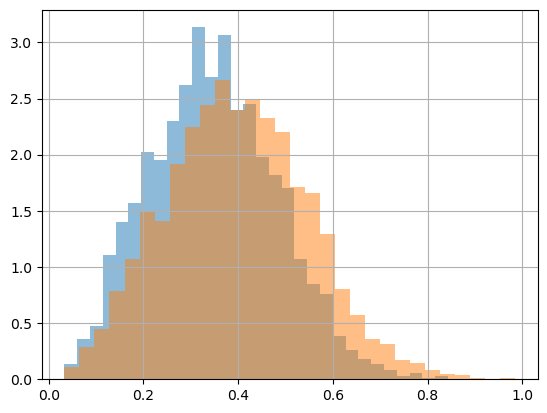

In [29]:
result_df[saltparcuts].z.hist(bins=30,alpha=0.5,density=True)
result_df.z.hist(bins=30,alpha=0.5,density=True)

<Axes: >

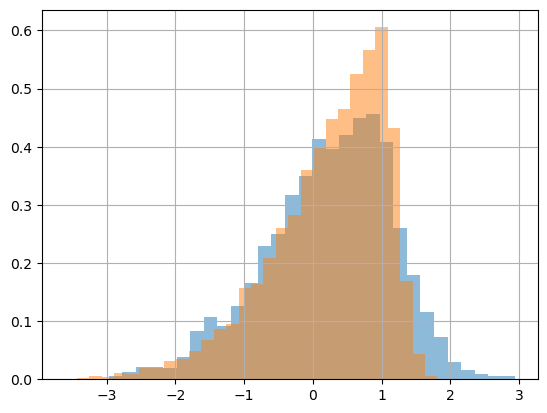

In [30]:
result_df[saltparcuts].x1.hist(bins=30, alpha=0.5, density=True)
lightcurves_after_quality_cut.source_x1.hist(bins=30, alpha=0.5, density=True)

<Axes: >

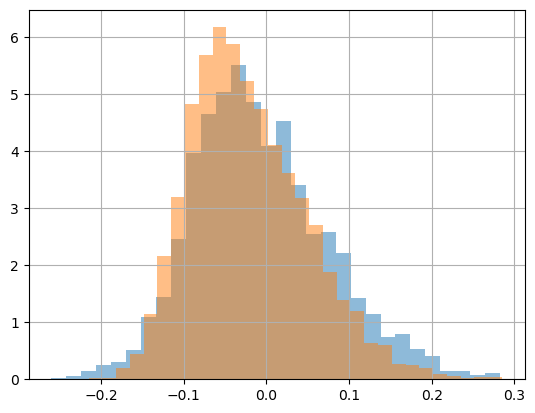

In [31]:
result_df[saltparcuts].c.hist(bins=30, alpha=0.5, density=True)
lightcurves_after_quality_cut.source_c.hist(bins=30, alpha=0.5, density=True)

In [32]:
result_df[saltparcuts]

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov,id,fit_error
0,1.0,79.0,13.508141,7.0,0.233123,0.0,61197.298459,0.401791,0.000043,1.352119e-06,...,0.000773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,NaN
1,1.0,101.0,15.515591,19.0,0.431061,0.0,61142.468682,0.532276,0.000019,9.127406e-07,...,0.001083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4381,1.0,101.0,25.447317,18.0,0.329924,0.0,60864.474395,0.226074,0.000033,7.681071e-07,...,0.000485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,659324.0,NaN
4382,1.0,102.0,4.951384,8.0,0.593357,0.0,61161.223732,0.364910,0.000012,5.386134e-07,...,0.000457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,659430.0,NaN


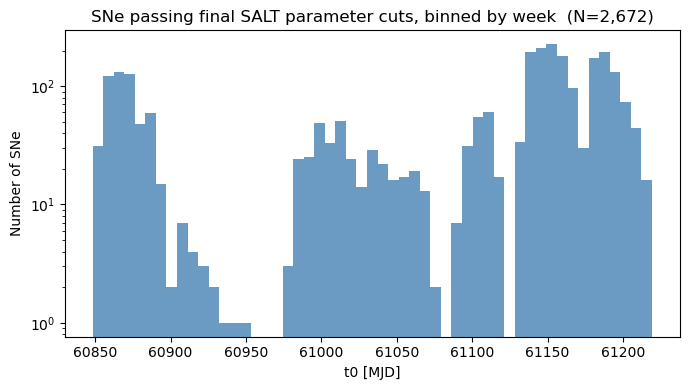

In [33]:
# Number of SNe binned by t0 (final SALT parameter cuts), weekly bins
t0_final = result_df[saltparcuts].t0

week_bins = np.arange(t0_final.min(), t0_final.max() + 7, 7)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(t0_final, bins=week_bins, color="steelblue", alpha=0.8)
ax.set(xlabel="t0 [MJD]", ylabel="Number of SNe",
       title=f"SNe passing final SALT parameter cuts, binned by week  (N={len(t0_final):,})")
plt.yscale("log")
plt.tight_layout()
plt.show()

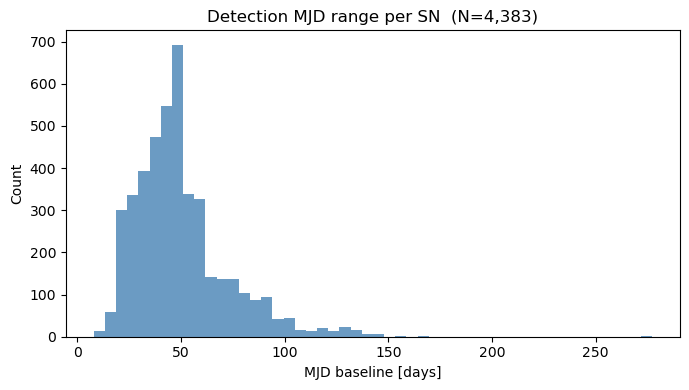

Median baseline: 45.9 days
Mean   baseline: 49.9 days


In [34]:
# MJD baseline (max - min) for all detections of each simulated SN
mjd_flat = lightcurves_after_quality_cut["lightcurve.mjd"]
mjd_range = mjd_flat.groupby(level=0).agg(lambda x: x.max() - x.min())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mjd_range, bins=50, color="steelblue", alpha=0.8)
ax.set(xlabel="MJD baseline [days]", ylabel="Count",
       title=f"Detection MJD range per SN  (N={len(mjd_range):,})")
plt.tight_layout()
plt.show()

print(f"Median baseline: {mjd_range.median():.1f} days")
print(f"Mean   baseline: {mjd_range.mean():.1f} days")

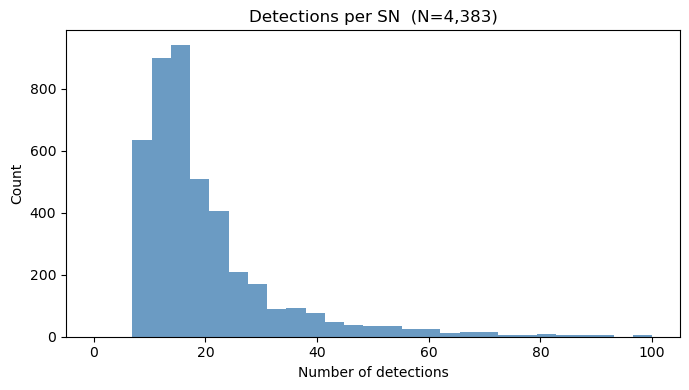

Median detections: 16.0
Mean   detections: 25.1
Min   detections: 7.0


In [35]:
# Number of detections per simulated SN
n_detections = lightcurves_after_quality_cut["lightcurve.mjd"].groupby(level=0).count()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(n_detections, bins=np.linspace(0, 100, 30), color="steelblue", alpha=0.8)
ax.set(xlabel="Number of detections", ylabel="Count",
       title=f"Detections per SN  (N={len(n_detections):,})")
plt.tight_layout()
plt.show()

print(f"Median detections: {n_detections.median():.1f}")
print(f"Mean   detections: {n_detections.mean():.1f}")
print(f"Min   detections: {n_detections.min():.1f}")

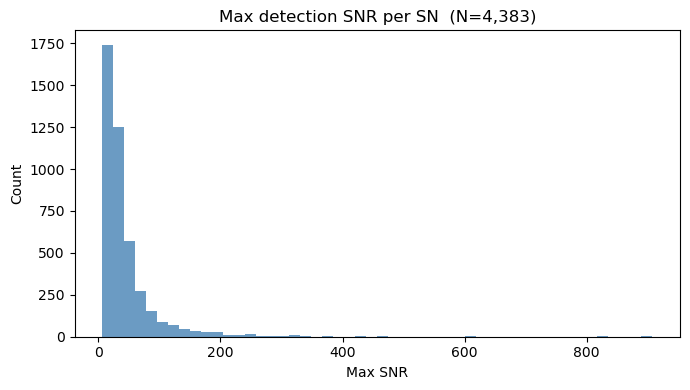

Median max SNR: 29.6
Mean   max SNR: 47.1


In [36]:
# Max SNR per SN (after quality cuts)
max_snr = lightcurves_after_quality_cut["lightcurve.snr"].groupby(level=0).max()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(max_snr, bins=50, color="steelblue", alpha=0.8)
ax.set(xlabel="Max SNR", ylabel="Count",
       title=f"Max detection SNR per SN  (N={len(max_snr):,})")
plt.tight_layout()
plt.show()

print(f"Median max SNR: {max_snr.median():.1f}")
print(f"Mean   max SNR: {max_snr.mean():.1f}")